# Overlap of krill fishing and the krill-carbon zone typology
- Catch (during the summer) distribution spatio-temporal
- Harvesting distribution in each category
- Number of krill caught in each category
- Map the overlap

In [45]:
# import libraries
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import math
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.cm as cm

In [46]:
# To be change with local directory of the data (file too heavy to be on git)
import os
os.chdir('C:/Users/anael/Documents/PhD/4_krill_fisheries_Carbon_seq_time/Git_repo/Key_Areas_krill_carbon_sequestration')
#os.chdir('./Key_Areas_krill_carbon_sequestration/outputs_formated_data/')

# Load data

In [47]:
zones = pd.read_csv('./output_results/zones_krill_carbon.csv').dropna(subset=['Zone_type'])
zones #1762  

,latitude,longitude,label_grid,mean_seq_time,krill_adult_log,Upper_tiertile_seq,Upper_tiertile_krill,Zone_type
0,-75,-179,0.0,646.910548,1.08086,1.0,0.0,1.0
1,-75,-177,0.0,601.882341,1.38079,1.0,0.0,1.0
2,-75,-175,0.0,655.238074,1.51197,1.0,0.0,1.0
3,-75,-173,0.0,641.075711,1.53273,1.0,0.0,1.0
4,-75,-171,0.0,620.753036,1.70495,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...
2821,-45,63,0.0,320.323902,0.00001,0.0,0.0,0.0
2822,-45,65,0.0,257.610200,0.00762,0.0,0.0,0.0
2823,-45,67,0.0,238.034583,0.10288,0.0,0.0,0.0
2824,-45,69,0.0,314.399618,0.05762,0.0,0.0,0.0


In [48]:
catch = xr.open_dataset('./outputs_formated_data/Krill_catch_array_final_all_summer.nc')
# catch = catch.to_dataframe().reset_index().drop(['variable'], axis =1) # 940 rows × 3 columns
# catch = catch.dropna()
# catch.set_index(['latitude', 'longitude'], inplace = True)
catch

<xarray.Dataset>
Dimensions:                   (latitude: 10, longitude: 180)
Coordinates:
  * latitude                  (latitude) int32 -69 -67 -65 -63 ... -55 -53 -51
  * longitude                 (longitude) int32 -179 -177 -175 ... 175 177 179
Data variables:
    krill_greenweight_kg      (latitude, longitude) float64 ...
    krill_greenweight_kg_log  (latitude, longitude) float64 ...

In [49]:
# save xarray of the temporal average over the three periods
catch_period1 = xr.open_dataset('./outputs_formated_data/Krill_catch_array_final_1_summer.nc')
catch_period2 = xr.open_dataset('./outputs_formated_data/Krill_catch_array_final_2_summer.nc')
catch_period3 = xr.open_dataset('./outputs_formated_data/Krill_catch_array_final_3_summer.nc')

# Maps the overlap between the Zones types and fishing grounds

In [50]:
# load the Zones types as xarray
zones_array = xr.open_dataset('./output_results/zones_krill_carbon.nc').to_array()
# zones_array = zones_array.sel(latitude=zones_array.latitude[zones_array.latitude < -50])
lat_mask = zones_array.latitude < -50
lat_mask = lat_mask.broadcast_like(zones_array)
zones_array = zones_array.where(lat_mask, drop=True)
zones_array

<xarray.DataArray (variable: 1, latitude: 13, longitude: 180)>
array([[[ 1.,  1.,  1., ...,  2.,  3., nan],
        [ 1.,  3.,  3., ...,  3.,  3., nan],
        [ 3.,  3.,  0., ...,  3.,  1., nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * latitude   (latitude) int32 -75 -73 -71 -69 -67 -65 ... -59 -57 -55 -53 -51
  * longitude  (longitude) int32 -179 -177 -175 -173 -171 ... 173 175 177 179
  * variable   (variable) object '__xarray_dataarray_variable__'

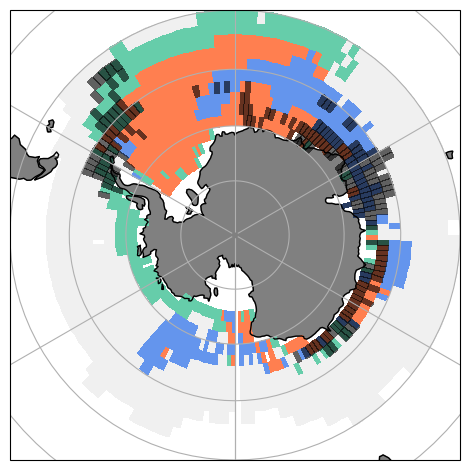

In [51]:
map_proj = ccrs.SouthPolarStereo()

p = zones_array.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    add_colorbar = False,
    subplot_kws={"projection": map_proj}, # the plot's projection
    levels=[1, 2, 3, 4], 
    colors =  ['#f0f0f0', 'cornflowerblue', 'mediumaquamarine', 'coral'],
    alpha = 1
) 

p2 = catch['krill_greenweight_kg_log'].plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    subplot_kws={"projection": map_proj},
    add_colorbar = False,
    #color ='orange', # check the grid
    levels=[1, 2, 3, 4],
    colors = 'black', #['white', 'cornflowerblue', 'mediumaquamarine', 'coral'], #  ,#orangered', 
    alpha = 0.6
)

p.axes.gridlines()
p.axes.add_feature(cfeature.LAND, color='grey')
p.axes.add_feature(cfeature.COASTLINE)
# cb = plt.colorbar(p2, label = 'Fishing density', shrink = 0.8)
# plt.legend()
#plt.title('Spatial overlap of the upper 1/3 quantile of the krill abundance, \n the time of carbon sequestration and the 2/3 upper \n quantile of the number of krill catch')
plt.title('')
plt.tight_layout()
# plt.savefig('./figures/p_overlap_zone_fishing_summer.png', bbox_inches='tight', dpi=300)

plt.show(p2)

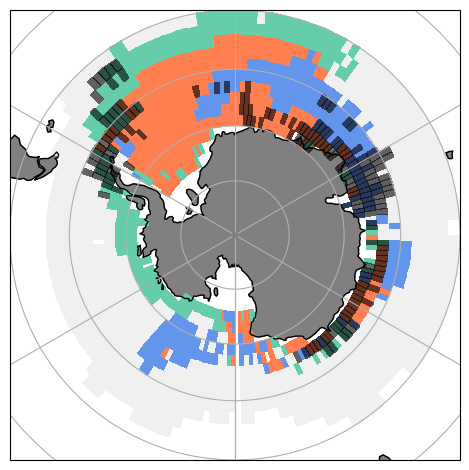

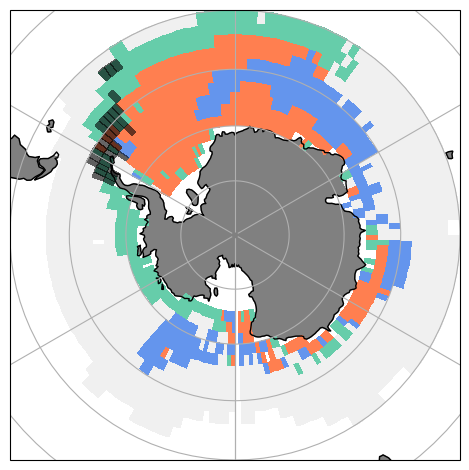

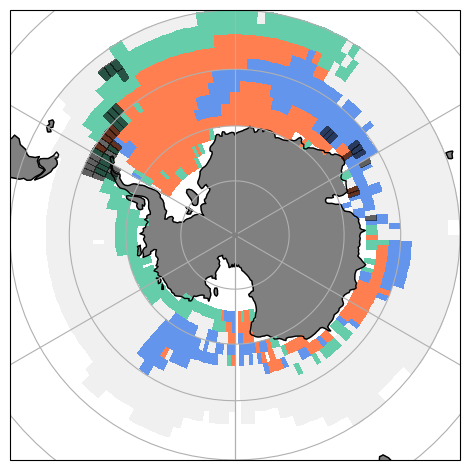

In [52]:
# Map Period 1 overlap

map_proj = ccrs.SouthPolarStereo()

p = zones_array.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    add_colorbar = False,
    subplot_kws={"projection": map_proj}, # the plot's projection
    levels=[1, 2, 3, 4], 
    colors =  ['#f0f0f0', 'cornflowerblue', 'mediumaquamarine', 'coral']
) 

p2 = catch_period1['krill_greenweight_kg_log'].plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    subplot_kws={"projection": map_proj},
    add_colorbar = False,
    #color ='orange', # check the grid
    levels=[1, 2, 3, 4],
    colors = 'black', #['white', 'cornflowerblue', 'mediumaquamarine', 'coral'], # 'black' ,#orangered', 
    alpha = 0.6
)

p.axes.gridlines()
p.axes.add_feature(cfeature.LAND, color='grey')
p.axes.add_feature(cfeature.COASTLINE)
#cb = plt.colorbar(p, label = 'overlap', shrink = 0.8)
#plt.legend()
#plt.title('Spatial overlap of the upper 1/3 quantile of the krill abundance, \n the time of carbon sequestration and the 2/3 upper \n quantile of the number of krill catch')
plt.title('')
plt.tight_layout()
# plt.savefig('./figures/p_overlap_zone_fishingP1_summer.png', bbox_inches='tight', dpi=300)

plt.show(p2)

# MMap Period 2 overlap

map_proj = ccrs.SouthPolarStereo()

p = zones_array.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    add_colorbar = False,
    subplot_kws={"projection": map_proj}, # the plot's projection
    levels=[1, 2, 3, 4], 
    colors =  ['#f0f0f0', 'cornflowerblue', 'mediumaquamarine', 'coral']
) 

p2 = catch_period2['krill_greenweight_kg_log'].plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    subplot_kws={"projection": map_proj},
    add_colorbar = False,
    #color ='orange', # check the grid
    levels=[1, 2, 3, 4],
    colors = 'black', #['white', 'cornflowerblue', 'mediumaquamarine', 'coral'], # 'black' ,#orangered', 
    alpha = 0.6
)

p.axes.gridlines()
p.axes.add_feature(cfeature.LAND, color='grey')
p.axes.add_feature(cfeature.COASTLINE)
#cb = plt.colorbar(p, label = 'overlap', shrink = 0.8)
#plt.legend()
#plt.title('Spatial overlap of the upper 1/3 quantile of the krill abundance, \n the time of carbon sequestration and the 2/3 upper \n quantile of the number of krill catch')
plt.title('')
plt.tight_layout()
# plt.savefig('./figures/p_overlap_zone_fishingP2_summer.png', bbox_inches='tight', dpi=300)

plt.show(p2)

# Map Period 3 overlap

map_proj = ccrs.SouthPolarStereo()

p = zones_array.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    add_colorbar = False,
    subplot_kws={"projection": map_proj}, # the plot's projection
    levels=[1, 2, 3, 4], 
    colors =  ['#f0f0f0', 'cornflowerblue', 'mediumaquamarine', 'coral']
) 

p2 = catch_period3['krill_greenweight_kg_log'].plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    subplot_kws={"projection": map_proj},
    add_colorbar = False,
    #color ='orange', # check the grid
    levels=[1, 2, 3, 4],
    colors = 'black', #['white', 'cornflowerblue', 'mediumaquamarine', 'coral'], # 'black' ,#orangered', 
    alpha = 0.6
)

p.axes.gridlines()
p.axes.add_feature(cfeature.LAND, color='grey')
p.axes.add_feature(cfeature.COASTLINE)
#cb = plt.colorbar(p, label = 'overlap', shrink = 0.8)
#plt.legend()
#plt.title('Spatial overlap of the upper 1/3 quantile of the krill abundance, \n the time of carbon sequestration and the 2/3 upper \n quantile of the number of krill catch')
plt.title('')
plt.tight_layout()
# plt.savefig('./figures/p_overlap_zone_fishingP3_summer.png', bbox_inches='tight', dpi=300)

plt.show(p2)

# Fishing in the different zone types: 
### how much krill is caught in each area type and what is the distribution of catch accross the krill and sequestration time distributions ?

In [53]:
catch

<xarray.Dataset>
Dimensions:                   (latitude: 10, longitude: 180)
Coordinates:
  * latitude                  (latitude) int32 -69 -67 -65 -63 ... -55 -53 -51
  * longitude                 (longitude) int32 -179 -177 -175 ... 175 177 179
Data variables:
    krill_greenweight_kg      (latitude, longitude) float64 ...
    krill_greenweight_kg_log  (latitude, longitude) float64 ...

In [54]:
catch_df = catch[['krill_greenweight_kg_log', 'krill_greenweight_kg']].to_dataframe().dropna().reset_index()
zones_catch = pd.merge(zones, catch_df, how='left').set_index(['latitude', 'longitude'])
zones_catch['krill_greenweight_kg_log'] = zones_catch['krill_greenweight_kg_log'].fillna(0)
zones_catch['krill_greenweight_kg'] = zones_catch['krill_greenweight_kg'].fillna(0)
zones_catch

label_grid  mean_seq_time  krill_adult_log  \
latitude longitude                                               
-75      -179              0.0     646.910548          1.08086   
         -177              0.0     601.882341          1.38079   
         -175              0.0     655.238074          1.51197   
         -173              0.0     641.075711          1.53273   
         -171              0.0     620.753036          1.70495   
...                        ...            ...              ...   
-45       63               0.0     320.323902          0.00001   
          65               0.0     257.610200          0.00762   
          67               0.0     238.034583          0.10288   
          69               0.0     314.399618          0.05762   
          71               0.0     306.357993          0.00012   

                    Upper_tiertile_seq  Upper_tiertile_krill  Zone_type  \
latitude longitude                                                        
-75      -179                      1.0                   0.0        1.0   
         -177                      1.0                   0.0        1.0   
         -175                      1.0                   0.0        1.0   
         -173                      1.0                   0.0        1.0   
         -171                      1.0                   1.0        3.0   
...                                ...                   ...        ...   
-45       63                       0.0                   0.0        0.0   
          65                       0.0                   0.0        0.0   
          67                       0.0                   0.0        0.0   
          69                       0.0                   0.0        0.0   
          71                       0.0                   0.0        0.0   

                    krill_greenweight_kg_log  krill_greenweight_kg  
latitude longitude                                                  
-75      -179                            0.0                   0.0  
         -177                            0.0                   0.0  
         -175                            0.0                   0.0  
         -173                            0.0                   0.0  
         -171                            0.0                   0.0  
...                                      ...                   ...  
-45       63                             0.0                   0.0  
          65                             0.0                   0.0  
          67                             0.0                   0.0  
          69                             0.0                   0.0  
          71                             0.0                   0.0  

[1773 rows x 8 columns]

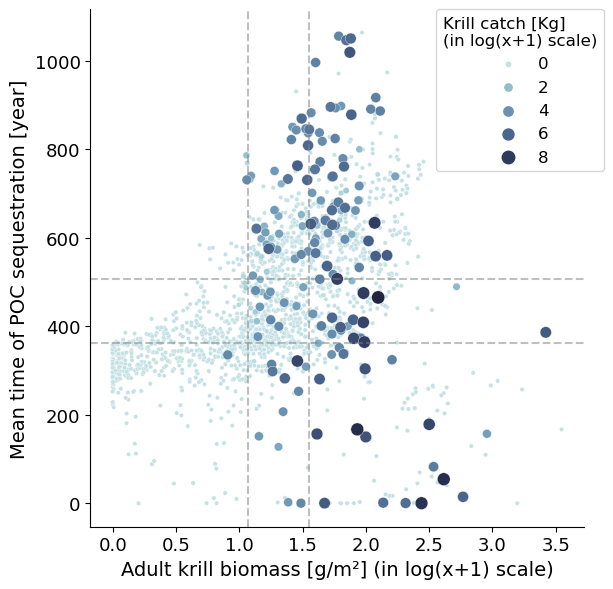

In [55]:
g=sns.relplot(x="krill_adult_log", y="mean_seq_time", 
            data=zones_catch.sort_values(by=['krill_greenweight_kg_log']),
            hue='krill_greenweight_kg_log', 
            size = 'krill_greenweight_kg_log',
            palette = sns.cubehelix_palette(rot=-.2, as_cmap=True),
           sizes = (10,90),
           label='', legend=True,
              height=6, aspect = 0.8)


# # Step 1: Get all legend entries (handles + labels)
# handles, labels = g._legend.legendHandles, [t.get_text() for t in g._legend.texts]

# # Step 2: Keep only the size legend entries
# # Find where size legend starts (after all Zone_type labels)
# size_start = labels.index("krill_catch_density_log")

# # Step 3: Keep only the size-related entries
# new_handles = handles[size_start + 1:]  # skip the variable name
# new_labels = labels[size_start + 1:]    # skip the variable name


# # Step 4: Remove existing legend, and add a new one with only size info
g._legend.remove()
g.ax.legend(title="Krill catch [Kg] \n(in log(x+1) scale)", 
            bbox_to_anchor=(0.7, 1), borderaxespad=0., title_fontsize=12, fontsize=12)


plt.axvline(x=1.070907, alpha = 0.5, color='grey', linestyle='--')
plt.axvline(x=1.548244, alpha = 0.5, color='grey', linestyle='--')

plt.axhline(y=361.922103, alpha = 0.5, color='grey', linestyle='--')
plt.axhline(y=507.647916, alpha = 0.5, color='grey', linestyle='--')

plt.xlabel('Adult krill biomass [g/m²] (in log(x+1) scale)', fontsize = 14)
plt.ylabel('Mean time of POC sequestration [year]', fontsize = 14)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# plt.text(3.8, 200, '--- :  1/3 quantiles')

plt.tight_layout()
# plt.savefig('./figures/biplot_fishing.png',bbox_inches='tight', dpi=300)

plt.show()

In [56]:
zones_catch

label_grid  mean_seq_time  krill_adult_log  \
latitude longitude                                               
-75      -179              0.0     646.910548          1.08086   
         -177              0.0     601.882341          1.38079   
         -175              0.0     655.238074          1.51197   
         -173              0.0     641.075711          1.53273   
         -171              0.0     620.753036          1.70495   
...                        ...            ...              ...   
-45       63               0.0     320.323902          0.00001   
          65               0.0     257.610200          0.00762   
          67               0.0     238.034583          0.10288   
          69               0.0     314.399618          0.05762   
          71               0.0     306.357993          0.00012   

                    Upper_tiertile_seq  Upper_tiertile_krill  Zone_type  \
latitude longitude                                                        
-75      -179                      1.0                   0.0        1.0   
         -177                      1.0                   0.0        1.0   
         -175                      1.0                   0.0        1.0   
         -173                      1.0                   0.0        1.0   
         -171                      1.0                   1.0        3.0   
...                                ...                   ...        ...   
-45       63                       0.0                   0.0        0.0   
          65                       0.0                   0.0        0.0   
          67                       0.0                   0.0        0.0   
          69                       0.0                   0.0        0.0   
          71                       0.0                   0.0        0.0   

                    krill_greenweight_kg_log  krill_greenweight_kg  
latitude longitude                                                  
-75      -179                            0.0                   0.0  
         -177                            0.0                   0.0  
         -175                            0.0                   0.0  
         -173                            0.0                   0.0  
         -171                            0.0                   0.0  
...                                      ...                   ...  
-45       63                             0.0                   0.0  
          65                             0.0                   0.0  
          67                             0.0                   0.0  
          69                             0.0                   0.0  
          71                             0.0                   0.0  

[1773 rows x 8 columns]

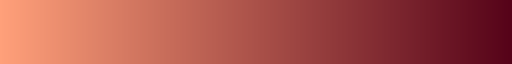

In [57]:
sns.color_palette("blend:#ffa07a,#cd5c5c", as_cmap=True) 
sns.color_palette("blend:#ffa07a,#800000", as_cmap=True) #560319
sns.color_palette("blend:#ffa07a,#560319", as_cmap=True)

C:\Users\anael\AppData\Local\Temp\ipykernel_16604\4231074722.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Blues")  # ou "YlGn", "summer", etc.


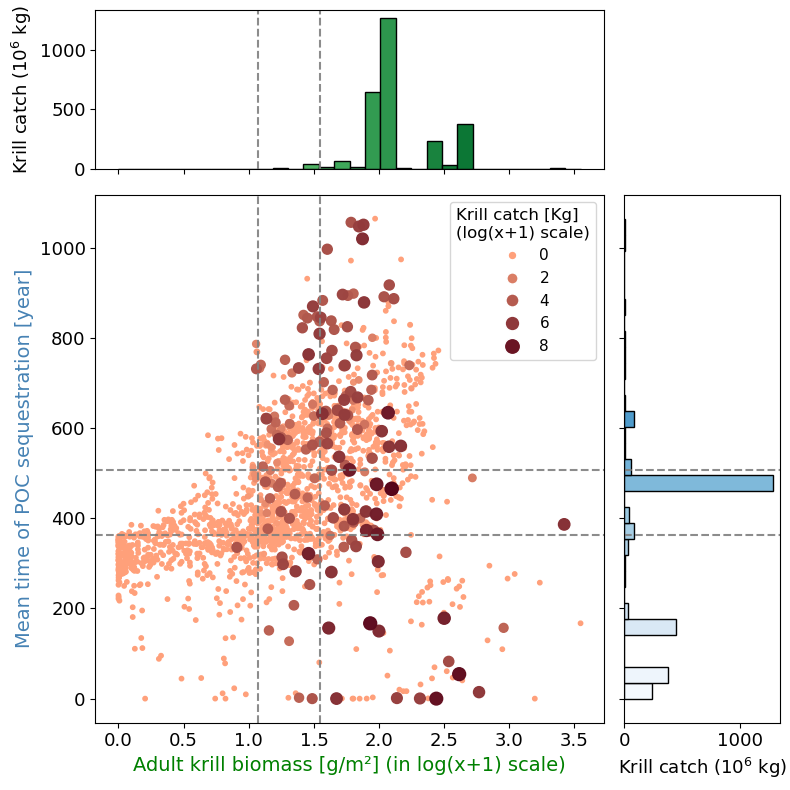

In [58]:
# Data prep
df = zones_catch.sort_values(by=['krill_greenweight_kg_log']).copy()
x = df["krill_adult_log"]
y = df["mean_seq_time"]
weights = df["krill_greenweight_kg"] / 1e6  # to plot in millions of kg

sizes = 10 + 80 * ((df['krill_greenweight_kg_log'] - df['krill_greenweight_kg_log'].min()) /
                   (df['krill_greenweight_kg_log'].max() - df['krill_greenweight_kg_log'].min()))

colors = df["krill_greenweight_kg_log"]

# Layout: Joint + Marginals
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)
ax_joint = fig.add_subplot(gs[1:4, 0:3])
ax_marg_x = fig.add_subplot(gs[0, 0:3], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs[1:4, 3], sharey=ax_joint)

# Joint scatter plot
cmap_krill = sns.color_palette("blend:#ffa07a,#560319", as_cmap=True)
sc = ax_joint.scatter(x, y, c=colors, s=sizes, cmap=cmap_krill, alpha=0.99) # sns.cubehelix_palette(rot=-.2, as_cmap=True)

ax_joint.set_xlabel("Adult krill biomass [g/m²] (in log(x+1) scale)", fontsize=14, color='green')
ax_joint.set_ylabel("Mean time of POC sequestration [year]", fontsize=14, color='steelblue')

ax_joint.axvline(x=1.070907, alpha = 0.9, color='grey', linestyle='--')
ax_joint.axvline(x=1.548244, alpha = 0.9, color='grey', linestyle='--')

ax_joint.axhline(y=361.922103, alpha = 0.9, color='grey', linestyle='--')
ax_joint.axhline(y=507.647916, alpha = 0.9, color='grey', linestyle='--')

ax_joint.tick_params(axis='both', labelsize=13)




# Marginal histogram on x-axis: weighted by krill catch
# ax_marg_x.hist(x, bins=30, weights=weights, color="gray", edgecolor='black')
# Définir le nombre de bins
n_bins = 30

# Générer les couleurs depuis une colormap
colors_x = plt.cm.Greens(np.linspace(0.3, 1, n_bins))  # dégradé du vert clair au foncé

# Calculer manuellement l'histogramme
hist_vals_x, bin_edges_x = np.histogram(x, bins=n_bins, weights=weights)

# Tracer chaque barre avec la bonne couleur
for i in range(n_bins):
    ax_marg_x.bar(
        (bin_edges_x[i] + bin_edges_x[i+1]) / 2,      # position x (centre de la barre)
        hist_vals_x[i],                               # hauteur
        width=bin_edges_x[i+1] - bin_edges_x[i],      # largeur du bin
        color=colors_x[i],
        edgecolor='black',
        align='center'
    )

ax_marg_x.set_ylabel('Krill catch ($10^6$ kg)', fontsize=13)
ax_marg_x.tick_params(labelbottom=False)

ax_marg_x.axvline(x=1.070907, alpha = 0.9, color='grey', linestyle='--')
ax_marg_x.axvline(x=1.548244, alpha = 0.9, color='grey', linestyle='--')

ax_marg_x.tick_params(axis='both', labelsize=13)




# Marginal histogram on y-axis: weighted by krill catch
# Définir les bins
bins = np.linspace(min(y), max(y), 31)
hist_vals, bin_edges = np.histogram(y, bins=bins, weights=weights)

# Colormap du vert clair au vert foncé
cmap = cm.get_cmap("Blues")  # ou "YlGn", "summer", etc.
norm = mcolors.Normalize(vmin=bin_edges[0], vmax=bin_edges[-1])

# Tracer les barres une par une avec couleur graduée
for i in range(len(hist_vals)):
    bar_color = cmap(norm((bin_edges[i] + bin_edges[i+1]) / 2))
    ax_marg_y.barh(
        y=(bin_edges[i] + bin_edges[i+1]) / 2,  # position au milieu du bin
        width=hist_vals[i],
        height=bin_edges[i+1] - bin_edges[i],
        color=bar_color,
        edgecolor='black'
    )
    
ax_marg_y.set_xlabel('Krill catch ($10^6$ kg)', fontsize=13)
ax_marg_y.tick_params(labelleft=False)

ax_marg_y.axhline(y=361.922103, alpha = 0.9, color='grey', linestyle='--')
ax_marg_y.axhline(y=507.647916, alpha = 0.9, color='grey', linestyle='--')

ax_marg_y.tick_params(axis='both', labelsize=13)

# Colorbar
# cbar = fig.colorbar(sc, ax=ax_joint, orientation='vertical', pad=0.02)
# cbar.set_label("log(Krill greenweight)", fontsize=11)

plt.tight_layout()



######## ctach legend 
# 1. Utiliser la même normalisation que pour le scatter
norm = mcolors.Normalize(vmin=df['krill_greenweight_kg_log'].min(),
                         vmax=df['krill_greenweight_kg_log'].max())

# 3. Définir les valeurs représentatives que tu veux dans la légende
legend_vals = [0, 2, 4, 6, 8]  # log(Kg)

# 4. Créer les bulles de légende
legend_handles = []
for val in legend_vals:
    size = 40 + 110 * ((val - df['krill_greenweight_kg_log'].min()) /
                      (df['krill_greenweight_kg_log'].max() - df['krill_greenweight_kg_log'].min()))
    color = cmap_krill(norm(val))
    handle = plt.Line2D([], [], marker='o', linestyle='None',
                        markersize= np.sqrt(size), # sqrt because size in scatter is area
                        markerfacecolor=color,
                        markeredgecolor='white',
                        label=f"{val}")
    legend_handles.append(handle)

# 5. Ajouter la légende au plot principal
ax_joint.legend(handles=legend_handles,
                title="Krill catch [Kg]\n(log(x+1) scale)",
                loc='upper right',
                fontsize=11,
                title_fontsize=12,
                frameon=True)


# plt.savefig('./figures/biplot_fishing_histocolors_summer.png',bbox_inches='tight', dpi=300)
plt.show()


C:\Users\anael\AppData\Local\Temp\ipykernel_16604\2654213883.py:13: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles, labels = g._legend.legendHandles, [t.get_text() for t in g._legend.texts]


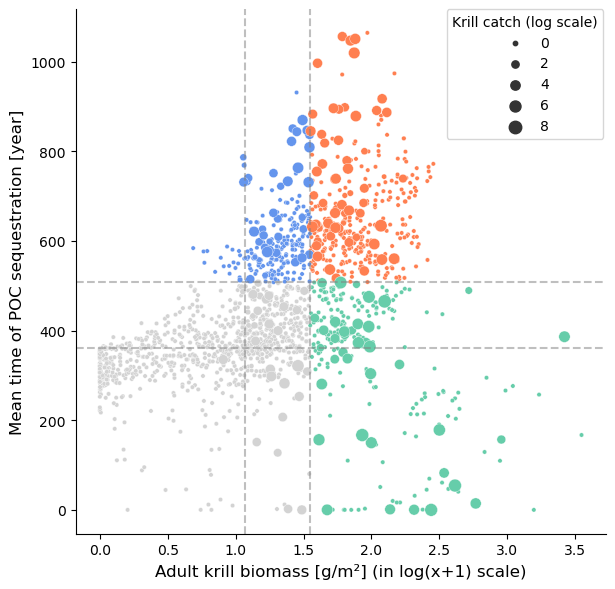

In [59]:
g=sns.relplot(x="krill_adult_log", y="mean_seq_time", 
            data=zones_catch.sort_values(by=['krill_greenweight_kg_log']),
            hue='Zone_type', 
            size = 'krill_greenweight_kg_log',
            #style="krill_catch_density_log",
            palette = ['lightgrey', 'cornflowerblue', 'mediumaquamarine', 'coral'], #sns.cubehelix_palette(rot=-.2, as_cmap=True),
           sizes = (10,90),
           label='krill catch density (log scale)', legend=True,
              height=6, aspect=0.8)


# Step 1: Get all legend entries (handles + labels)
handles, labels = g._legend.legendHandles, [t.get_text() for t in g._legend.texts]

# Step 2: Keep only the size legend entries
# Find where size legend starts (after all Zone_type labels)
size_start = labels.index("krill_greenweight_kg_log")

# Step 3: Keep only the size-related entries
new_handles = handles[size_start + 1:]  # skip the variable name
new_labels = labels[size_start + 1:]    # skip the variable name


# Step 4: Remove existing legend, and add a new one with only size info
g._legend.remove()
g.ax.legend(new_handles, new_labels, title="Krill catch (log scale)", bbox_to_anchor=(0.7, 1), borderaxespad=0.)


plt.axvline(x=1.070907, alpha = 0.5, color='grey', linestyle='--')
plt.axvline(x=1.548244, alpha = 0.5, color='grey', linestyle='--')

plt.axhline(y=361.922103, alpha = 0.5, color='grey', linestyle='--')
plt.axhline(y=507.647916, alpha = 0.5, color='grey', linestyle='--')


plt.xlabel('Adult krill biomass [g/m²] (in log(x+1) scale)', fontsize = 'large')
plt.ylabel('Mean time of POC sequestration [year]', fontsize = 'large')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# plt.text(3.8, 200, '--- :  1/3 quantiles')

plt.tight_layout()
# plt.savefig('./figures/biplot_fishing_colors.png',bbox_inches='tight', dpi=300)

plt.show()

# Key numbers

- total amount of krill catch
- mean density of krill catch
- amount of krill catch in each zone type
- % of catch taken in each zone type

# Area calculation

- Area of the fishing ground total and for each period
- Area of the overlap of each zone type with fishing

In [60]:
# load area file from OCIM
OCIM = xr.open_dataset('./outputs_formated_data/fseq_OCIM2_48L_interpolated_SO.nc')

# transform area array into a dataframe and crop the file à -45°S
area_df = OCIM[['AREA', 'MASK']].isel(depth=0).to_dataframe().drop(['depth'], axis = 1).reset_index()
area_df = area_df[area_df['latitude'] <=-45].set_index(['latitude', 'longitude'])

## calculate the area of the ocean (remove land) => multiply be the proportion of the ocean in cell (= MASK : 1=ocean, 0=land, or %o each)
area_df['True_area'] = area_df['AREA']*area_df['MASK']
area_df # 3240  rows

AREA      MASK     True_area
latitude longitude                                      
-79      -179.0     9.332850e+09  0.061111  5.703408e+08
         -177.0     9.332850e+09  0.061111  5.703408e+08
         -175.0     9.332850e+09  0.061111  5.703408e+08
         -173.0     9.332850e+09  0.061111  5.703408e+08
         -171.0     9.332850e+09  0.061111  5.703408e+08
...                          ...       ...           ...
-45       171.0     3.458337e+10  0.750000  2.593752e+10
          173.0     3.458337e+10  1.000000  3.458337e+10
          175.0     3.458337e+10  1.000000  3.458337e+10
          177.0     3.458337e+10  1.000000  3.458337e+10
          179.0     3.458337e+10  1.000000  3.458337e+10

[3240 rows x 3 columns]

### Area of fishing grounds

In [61]:
# load the catch data 
catch = pd.read_csv('./outputs_formated_data/Krill_catch_final_summer.csv').set_index(['latitude', 'longitude']).dropna()
catch_p1 = pd.read_csv('./outputs_formated_data/Krill_catch_final_1_summer.csv').set_index(['latitude', 'longitude']).dropna()
catch_p2 = pd.read_csv('./outputs_formated_data/Krill_catch_final_2_summer.csv').set_index(['latitude', 'longitude']).dropna()
catch_p3 = pd.read_csv('./outputs_formated_data/Krill_catch_final_3_summer.csv').set_index(['latitude', 'longitude']).dropna()

In [62]:
#join the areas
catch = catch.join(area_df , how='left')
catch_p1 = catch_p1.join(area_df , how='left')
catch_p2 = catch_p2.join(area_df , how='left')
catch_p3 = catch_p3.join(area_df , how='left')

# sum the area to get the total area fished in eahc period
# here numbers before joining with zone data: its all the fishing grounds (event those falling on cells that are not in the study area)
tot_area_fished  = catch.sum()['True_area']*0.000001
area_fished1 = catch_p1.sum()['True_area']*0.000001
area_fished2 = catch_p2.sum()['True_area']*0.000001 
area_fished3 = catch_p3.sum()['True_area']*0.000001 

In [63]:
print(tot_area_fished, area_fished1, area_fished2, area_fished3)

4178108.7114603864 3973943.510872957 742734.9860434794 910911.0707904693


In [64]:
# here numbers before joining with zone data: its all the catch (event those falling on cells that are not in the study area)
catchall = catch.sum()['krill_greenweight_kg']/1000 # tons
catchp1 = catch_p1.sum()['krill_greenweight_kg']/1000 # tons
catchp2 = catch_p2.sum()['krill_greenweight_kg']/1000 # tons
catchp3 = catch_p3.sum()['krill_greenweight_kg']/1000 # tons

print(catchall, catchp1, catchp2, catchp3)

2935925.170186762 985699.1246554 387472.64660000004 1562753.3989313617


# Fishing area in each zone type

How the catch are spread among the 3 identified zone types.

In [65]:
zones

,latitude,longitude,label_grid,mean_seq_time,krill_adult_log,Upper_tiertile_seq,Upper_tiertile_krill,Zone_type
0,-75,-179,0.0,646.910548,1.08086,1.0,0.0,1.0
1,-75,-177,0.0,601.882341,1.38079,1.0,0.0,1.0
2,-75,-175,0.0,655.238074,1.51197,1.0,0.0,1.0
3,-75,-173,0.0,641.075711,1.53273,1.0,0.0,1.0
4,-75,-171,0.0,620.753036,1.70495,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...
2821,-45,63,0.0,320.323902,0.00001,0.0,0.0,0.0
2822,-45,65,0.0,257.610200,0.00762,0.0,0.0,0.0
2823,-45,67,0.0,238.034583,0.10288,0.0,0.0,0.0
2824,-45,69,0.0,314.399618,0.05762,0.0,0.0,0.0


In [66]:
# here use inner join to drop cells that have a catch data but no zones data (see next sections)
zones_catch = pd.merge(zones, catch.reset_index().drop(['AREA', 'MASK', 'True_area'], axis=1), on = ['latitude', 'longitude'], how='inner').set_index(['latitude', 'longitude'])
zones_catch = zones_catch.join(other = area_df, how = 'left')

zones_catchp1 = pd.merge(zones, catch_p1.reset_index().drop(['AREA', 'MASK', 'True_area'], axis=1), on = ['latitude', 'longitude'], how='inner').set_index(['latitude', 'longitude'])
zones_catchp1 = zones_catchp1.join(other = area_df, how = 'left')

zones_catchp2 = pd.merge(zones, catch_p2.reset_index().drop(['AREA', 'MASK', 'True_area'], axis=1), on = ['latitude', 'longitude'], how='inner').set_index(['latitude', 'longitude'])
zones_catchp2 = zones_catchp2.join(other = area_df, how = 'left')

zones_catchp3 = pd.merge(zones, catch_p3.reset_index().drop(['AREA', 'MASK', 'True_area'], axis=1), on = ['latitude', 'longitude'], how='inner').set_index(['latitude', 'longitude'])
zones_catchp3 = zones_catchp3.join(other = area_df, how = 'left')

### Missing catch : cells for which we don't have time seq or krill pop data (so no category assigned) but which exist in the catch record

= 14 cells, representing 160164 km² and 657743.5 tones of krill caught.

In [67]:
zones_catchall = pd.merge(zones, catch.reset_index().drop(['AREA', 'MASK', 'True_area'], axis=1), 
                          on = ['latitude', 'longitude'], how='right').set_index(['latitude', 'longitude']).join(other = area_df, how = 'left')

missing_catch = zones_catchall[zones_catchall['Zone_type'].isna()]
print(missing_catch['True_area'].sum()*0.000001) # km²
print(missing_catch['krill_greenweight_kg'].sum()*0.001) # tons
print(100*(missing_catch['krill_greenweight_kg'].sum()*0.001)/catchall) # 8.25% of catches are set aside in the rest of the results
missing_catch # 14 rows

157722.49824071937
242264.87311446393
8.251738687844446


label_grid  mean_seq_time  krill_adult_log  \
latitude longitude                                               
-69       33               NaN            NaN              NaN   
          35               NaN            NaN              NaN   
          41               NaN            NaN              NaN   
-67       49               NaN            NaN              NaN   
          51               NaN            NaN              NaN   
          57               NaN            NaN              NaN   
          59               NaN            NaN              NaN   
-65      -63               NaN            NaN              NaN   
         -61               NaN            NaN              NaN   
          103              NaN            NaN              NaN   
          135              NaN            NaN              NaN   
-63      -57               NaN            NaN              NaN   
-61      -55               NaN            NaN              NaN   

                    Upper_tiertile_seq  Upper_tiertile_krill  Zone_type  \
latitude longitude                                                        
-69       33                       NaN                   NaN        NaN   
          35                       NaN                   NaN        NaN   
          41                       NaN                   NaN        NaN   
-67       49                       NaN                   NaN        NaN   
          51                       NaN                   NaN        NaN   
          57                       NaN                   NaN        NaN   
          59                       NaN                   NaN        NaN   
-65      -63                       NaN                   NaN        NaN   
         -61                       NaN                   NaN        NaN   
          103                      NaN                   NaN        NaN   
          135                      NaN                   NaN        NaN   
-63      -57                       NaN                   NaN        NaN   
-61      -55                       NaN                   NaN        NaN   

                    krill_greenweight_kg  krill_greenweight_kg_log  \
latitude longitude                                                   
-69       33                3.300000e+03                  3.518646   
          35                6.500000e+03                  3.812980   
          41                1.400000e+04                  4.146159   
-67       49                9.419700e+05                  5.974038   
          51                6.000000e+01                  1.785330   
          57                2.500000e+03                  3.398114   
          59                1.310259e+04                  4.117390   
-65      -63                1.041462e+07                  7.017644   
         -61                7.306167e+07                  7.863690   
          103               7.404500e+04                  4.869502   
          135               1.983702e+06                  6.297477   
-63      -57                2.545957e+07                  7.405851   
-61      -55                1.302898e+08                  8.114911   

                            AREA      MASK     True_area  
latitude longitude                                        
-69       33        1.752802e+10  0.116667  2.044936e+09  
          35        1.752802e+10  1.000000  1.752802e+10  
          41        1.752802e+10  0.116667  2.044936e+09  
-67       49        1.911083e+10  1.000000  1.911083e+10  
          51        1.911083e+10  0.127778  2.441940e+09  
          57        1.911083e+10  0.127778  2.441940e+09  
          59        1.911083e+10  1.000000  1.911083e+10  
-65      -63        2.067035e+10  0.138889  2.870882e+09  
         -61        2.067035e+10  0.138889  2.870882e+09  
          103       2.067035e+10  1.000000  2.067035e+10  
          135       2.067035e+10  1.000000  2.067035e+10  
-63      -57        2.220467e+10  1.000000  2.220467e+10  
-61      -55        2.3711

In [68]:
coords = pd.DataFrame({'latitude':np.repeat(np.arange(-75, -43, 2), 180), # -75 to -51
                       'longitude': np.tile(np.arange(-179, 180, 2), 16), # -179 to 179
                       'label_grid': np.zeros(2880)}).set_index(['latitude', 'longitude'])

coords = coords.sort_values(['latitude', 'longitude'])
# merge
missing_catch = coords.join(missing_catch.drop(['label_grid'], axis=1), how='left')

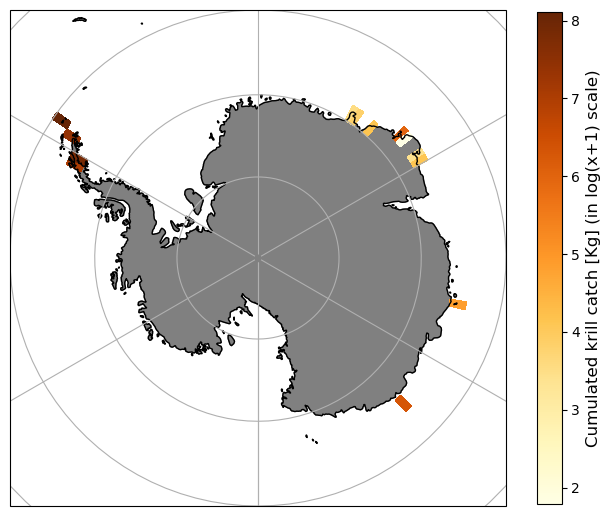

In [69]:
missing_catch_array = xr.Dataset.from_dataframe(missing_catch[['krill_greenweight_kg_log']]) # convert into xarrayDataset
missing_catch_array = xr.Dataset.to_array(missing_catch_array).sortby(['latitude', 'longitude'])
missing_catch_array = missing_catch_array.where(missing_catch_array.latitude <= -60, drop=True)

fig = plt.figure(figsize=(8, 8))

map_proj = ccrs.SouthPolarStereo()

p = missing_catch_array.plot(
    transform=ccrs.PlateCarree(),  # the data's projection
    add_colorbar = False,
    subplot_kws={"projection": map_proj}, # the plot's projection
    cmap= "YlOrBr"
)  


### Add features:
p.axes.gridlines()
p.axes.add_feature(cfeature.LAND, color='grey')
p.axes.add_feature(cfeature.COASTLINE)
plt.title('')

cb = plt.colorbar(p, label = '', shrink = 0.8)
cb.set_label(label='Cumulated krill catch [Kg] (in log(x+1) scale)', size=12)

# save
#os.chdir('./Key_Areas_krill_carbon_sequestration/figures/')
# plt.savefig('./figures/missing_summer_catch.png',bbox_inches='tight', dpi=300)

plt.show(p)

# Krill catch distribution in time seq and krill densities

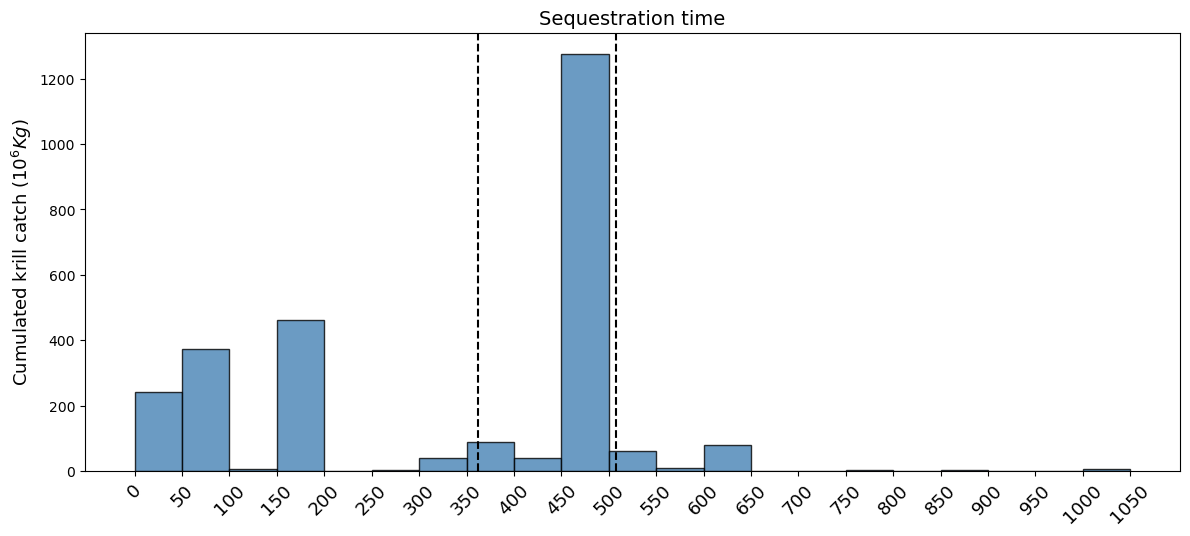

In [70]:
# Créer les subplots
fig, axes = plt.subplots(2,1 , figsize=(12, 10), sharex=True)
bins = list(range(0, 1100, 50))

# all years time seq
axes[1].hist(zones_catch['mean_seq_time'], bins=bins, weights=zones_catch['krill_greenweight_kg']/1000000,
             color='steelblue', edgecolor='black', alpha=0.8)

axes[1].axvline(x=361.922103, color='black', linestyle='--', linewidth=1.5) 
axes[1].axvline(x=507.647916, color='black', linestyle='--', linewidth=1.5) 

axes[1].set_title('Sequestration time', fontsize=14)
axes[1].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)

plt.xticks(bins, rotation=45, fontsize=13)

axes[0].remove()
plt.tight_layout()
# plt.savefig('./figures/histo_catch_tseq_summer.png', bbox_inches='tight', dpi=300)

plt.show()

In [71]:
catch_sum = zones_catch['krill_greenweight_kg'].sum()
# % catch in the lower tt
zones_catch_lowertt = zones_catch[zones_catch['mean_seq_time'] <= 361.922103]
print(100* zones_catch_lowertt['krill_greenweight_kg'].sum() / catch_sum)

# % of catch in the second tt
zones_catch_middlett = zones_catch[(zones_catch['mean_seq_time'] > 361.922103) & (zones_catch['mean_seq_time'] < 507.647916)]
print(100* zones_catch_middlett['krill_greenweight_kg'].sum() / catch_sum)

# % of catch in the upper tt
zones_catch_uppertt = zones_catch[zones_catch['mean_seq_time'] >= 507.647916]
print(100* zones_catch_uppertt['krill_greenweight_kg'].sum() / catch_sum)

41.73416595933712
54.39899902023888
3.8668350204239714


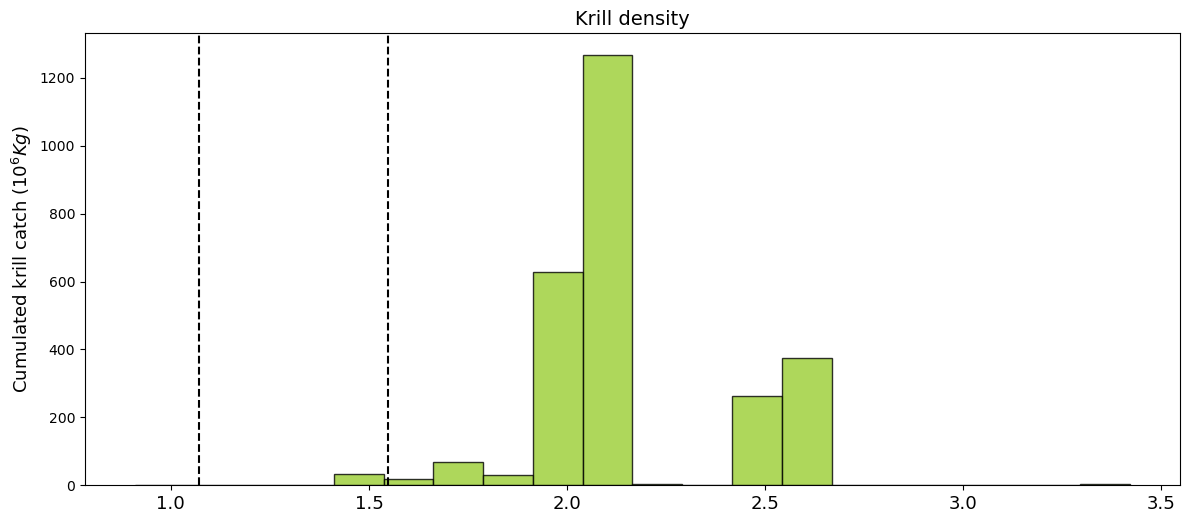

In [72]:
# Créer les subplots
fig, axes = plt.subplots(2,1 , figsize=(12, 10), sharex=True)
# bins = list(range(0, 1100, 50))

# all years krill density
axes[1].hist(zones_catch['krill_adult_log'], bins=20, weights=zones_catch['krill_greenweight_kg']/1000000,
             color='yellowgreen', edgecolor='black', alpha=0.8)

axes[1].axvline(x=1.070907, color='black', linestyle='--', linewidth=1.5) 
axes[1].axvline(x=1.548244, color='black', linestyle='--', linewidth=1.5)  

axes[1].set_title('Krill density', fontsize=14)
axes[1].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)

plt.xticks(fontsize=13)

axes[0].remove()
plt.tight_layout()
# plt.savefig('./figures/histo_catch_krill.png', bbox_inches='tight', dpi=300)

plt.show()


In [73]:
# % of catch in the upper tt
zones_catch_uppertt = zones_catch[zones_catch['krill_adult_log'] >= 1.548244]
print(100* zones_catch_uppertt['krill_greenweight_kg'].sum() / catch_sum)

98.54688193377913


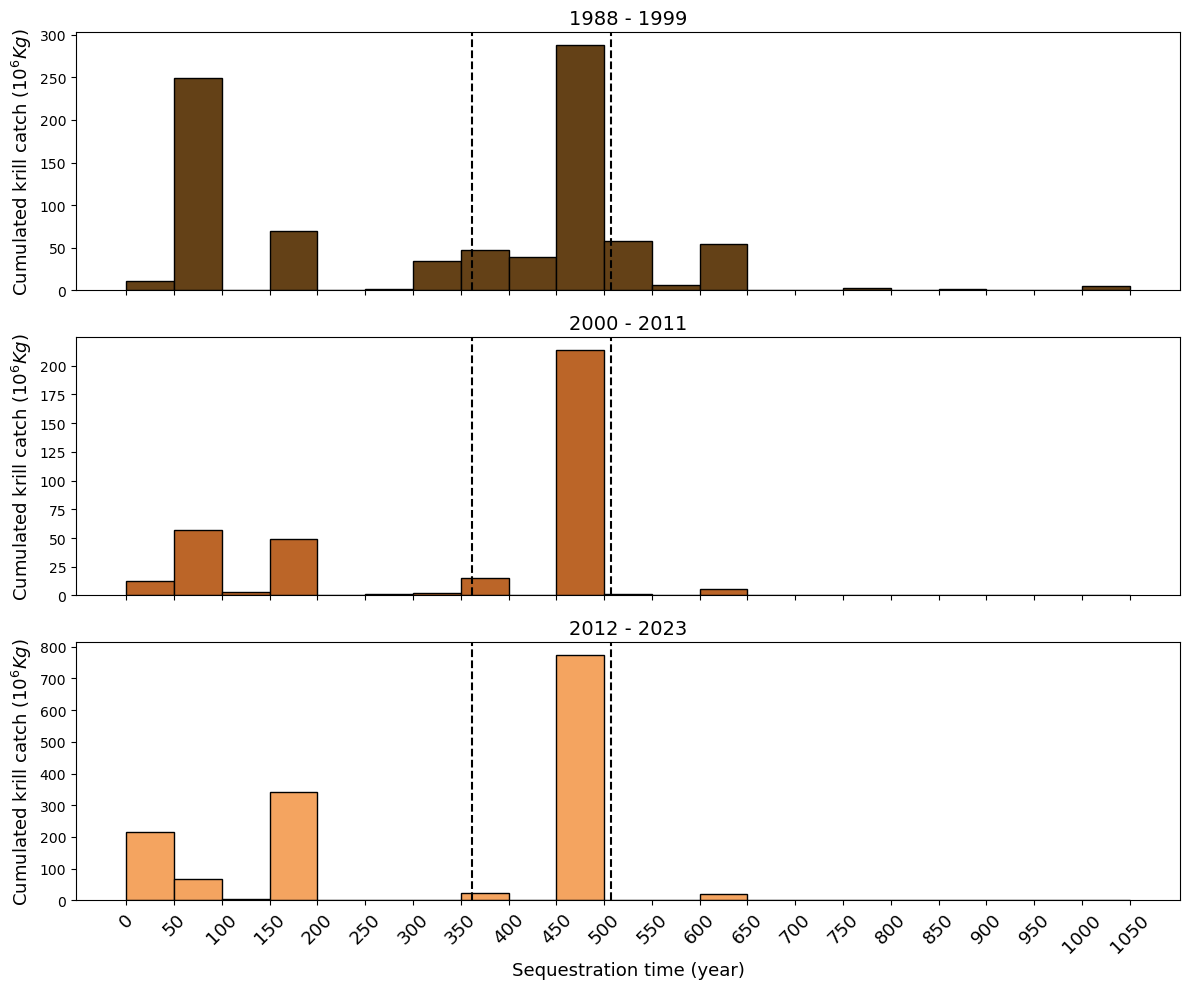

In [74]:
# Créer les subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
bins = list(range(0, 1100, 50))

# Period 1
axes[0].hist(zones_catchp1['mean_seq_time'], bins=bins, weights=zones_catchp1['krill_greenweight_kg']/1000000,
             color='#644117', edgecolor='black')

axes[0].axvline(x=361.922103, color='black', linestyle='--', linewidth=1.5) 
axes[0].axvline(x=507.647916, color='black', linestyle='--', linewidth=1.5)  

axes[0].set_title('1988 - 1999', fontsize=14)
axes[0].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)

# Period 2
axes[1].hist(zones_catchp2['mean_seq_time'], bins=bins, weights=zones_catchp2['krill_greenweight_kg']/1000000,
             color='#bb6528', edgecolor='black')
axes[1].axvline(x=361.922103, color='black', linestyle='--', linewidth=1.5) 
axes[1].axvline(x=507.647916, color='black', linestyle='--', linewidth=1.5)  

axes[1].set_title('2000 - 2011', fontsize=14)
axes[1].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)

# Period 3
axes[2].hist(zones_catchp3['mean_seq_time'], bins=bins, weights=zones_catchp3['krill_greenweight_kg']/1000000,
             color='#f4a460', edgecolor='black')
axes[2].axvline(x=361.922103, color='black', linestyle='--', linewidth=1.5) 
axes[2].axvline(x=507.647916, color='black', linestyle='--', linewidth=1.5)  

axes[2].set_title('2012 - 2023', fontsize=14)
axes[2].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)
axes[2].set_xlabel('Sequestration time (year)', fontsize=13)

# Axe x : ticks et mise en forme
plt.xticks(bins, rotation=45, fontsize=13)
plt.tight_layout()
# plt.savefig('./figures/histo_catch_tseq_summer.png', bbox_inches='tight', dpi=300)

plt.show()

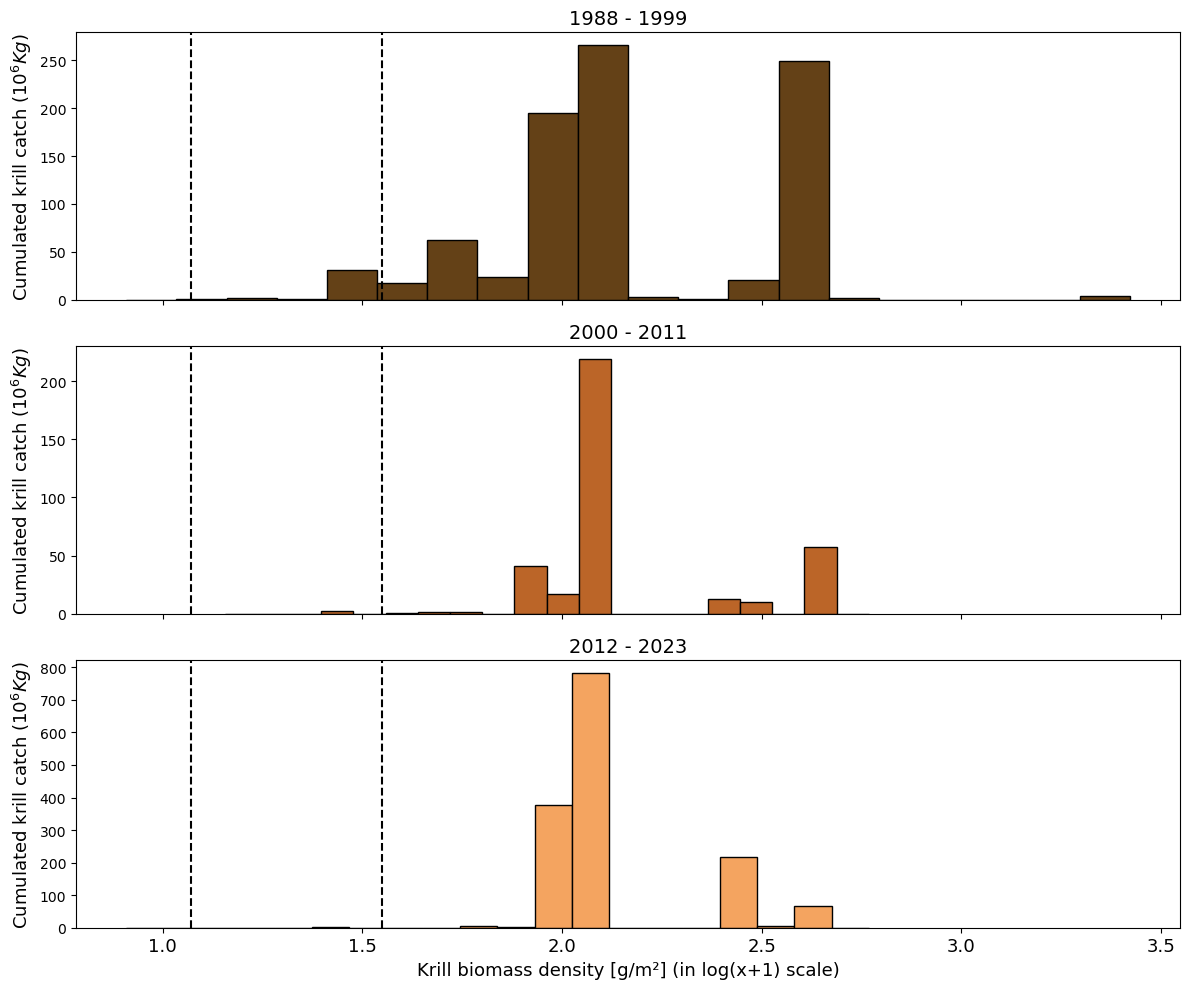

In [75]:
# Créer les subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
# bins = list(np.linspace(1, 3.5, 35))

# Period 1
axes[0].hist(zones_catchp1['krill_adult_log'], bins=20, weights=zones_catchp1['krill_greenweight_kg']/1000000,
             color='#644117', edgecolor='black')
axes[0].axvline(x=1.070907, color='black', linestyle='--', linewidth=1.5) 
axes[0].axvline(x=1.548244, color='black', linestyle='--', linewidth=1.5)  

axes[0].set_title('1988 - 1999', fontsize=14)
axes[0].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)

# Period 2
axes[1].hist(zones_catchp2['krill_adult_log'], bins=20, weights=zones_catchp2['krill_greenweight_kg']/1000000,
             color='#bb6528', edgecolor='black')
axes[1].axvline(x=1.070907, color='black', linestyle='--', linewidth=1.5) 
axes[1].axvline(x=1.548244, color='black', linestyle='--', linewidth=1.5)  

axes[1].set_title('2000 - 2011', fontsize=14)
axes[1].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)

# Period 3
axes[2].hist(zones_catchp3['krill_adult_log'], bins=20, weights=zones_catchp3['krill_greenweight_kg']/1000000,
             color='#f4a460', edgecolor='black')
axes[2].axvline(x=1.070907, color='black', linestyle='--', linewidth=1.5) 
axes[2].axvline(x=1.548244, color='black', linestyle='--', linewidth=1.5)  

axes[2].set_title('2012 - 2023', fontsize=14)
axes[2].set_ylabel('Cumulated krill catch ($10^6 Kg$)', fontsize=13)
axes[2].set_xlabel('Krill biomass density [g/m²] (in log(x+1) scale)', fontsize=13)

# Axe x : ticks et mise en forme
plt.xticks(fontsize=13)
plt.tight_layout()
# plt.savefig('./figures/histo_catch_krill_summer.png', bbox_inches='tight', dpi=300)

plt.show()

### Area of the fished zones per category

In [76]:
area_allcatch = zones_catch.groupby(['Zone_type'])[['True_area']].sum()
areas_p1 = zones_catchp1.groupby(['Zone_type'])[['True_area']].sum()
areas_p2 = zones_catchp2.groupby(['Zone_type'])[['True_area']].sum()
areas_p3 = zones_catchp3.groupby(['Zone_type'])[['True_area']].sum()

In [77]:
area_allcatch['Period'] = 'all_years'
areas_p1['Period'] = 'period_1'
areas_p2['Period'] = 'period_2'
areas_p3['Period'] = 'period_3'

In [78]:
display(area_allcatch,
areas_p1,
areas_p2,
areas_p3)

,True_area,Period
Zone_type,,
0.0,8.190858e+11,all_years
1.0,9.559375e+11,all_years
2.0,9.044656e+11,all_years
3.0,1.340897e+12,all_years


,True_area,Period
Zone_type,,
0.0,7.540331e+11,period_1
1.0,8.908578e+11,period_1
2.0,8.526374e+11,period_1
3.0,1.318693e+12,period_1


,True_area,Period
Zone_type,,
0.0,9.029887e+10,period_2
2.0,4.643916e+11,period_2
3.0,1.392570e+11,period_2


,True_area,Period
Zone_type,,
0.0,1.599274e+11,period_3
1.0,1.286251e+11,period_3
2.0,3.947559e+11,period_3
3.0,1.759444e+11,period_3


### Amount of krill caught in each category

Proportions are calculted over the total amount of krill caught **in the study area.**

In [79]:
krill_catch_allcatch = zones_catch.groupby(['Zone_type'])[['krill_greenweight_kg']].sum()
krill_catch_p1 = zones_catchp1.groupby(['Zone_type'])[['krill_greenweight_kg']].sum()
krill_catch_p2 = zones_catchp2.groupby(['Zone_type'])[['krill_greenweight_kg']].sum()
krill_catch_p3 = zones_catchp3.groupby(['Zone_type'])[['krill_greenweight_kg']].sum()

krill_catch_allcatch['tot_catch'] = zones_catch['krill_greenweight_kg'].sum()
krill_catch_p1['tot_catch'] = zones_catchp1['krill_greenweight_kg'].sum()
krill_catch_p2['tot_catch'] = zones_catchp2['krill_greenweight_kg'].sum()
krill_catch_p3['tot_catch'] = zones_catchp3['krill_greenweight_kg'].sum()

krill_catch_allcatch['prop_catch'] = krill_catch_allcatch['krill_greenweight_kg']/krill_catch_allcatch['tot_catch']
krill_catch_p1['prop_catch'] = krill_catch_p1['krill_greenweight_kg']/krill_catch_p1['tot_catch']
krill_catch_p2['prop_catch'] = krill_catch_p2['krill_greenweight_kg']/krill_catch_p2['tot_catch']
krill_catch_p3['prop_catch'] = krill_catch_p3['krill_greenweight_kg']/krill_catch_p3['tot_catch']

In [80]:
krill_catch_allcatch['Period'] = 'all_years'
krill_catch_p1['Period'] = 'period_1'
krill_catch_p2['Period'] = 'period_2'
krill_catch_p3['Period'] = 'period_3'

In [81]:
display(krill_catch_allcatch,
krill_catch_p1,
krill_catch_p2,
krill_catch_p3)

,krill_greenweight_kg,tot_catch,prop_catch,Period
Zone_type,,,,
0.0,3.287830e+07,2.693660e+09,0.012206,all_years
1.0,6.263761e+06,2.693660e+09,0.002325,all_years
2.0,2.556623e+09,2.693660e+09,0.949126,all_years
3.0,9.789564e+07,2.693660e+09,0.036343,all_years


,krill_greenweight_kg,tot_catch,prop_catch,Period
Zone_type,,,,
0.0,2.916022e+07,8.750931e+08,0.033322,period_1
1.0,6.009370e+06,8.750931e+08,0.006867,period_1
2.0,7.707218e+08,8.750931e+08,0.880731,period_1
3.0,6.920176e+07,8.750931e+08,0.079079,period_1


,krill_greenweight_kg,tot_catch,prop_catch,Period
Zone_type,,,,
0.0,2.232308e+06,3.625251e+08,0.006158,period_2
2.0,3.524386e+08,3.625251e+08,0.972177,period_2
3.0,7.854152e+06,3.625251e+08,0.021665,period_2


,krill_greenweight_kg,tot_catch,prop_catch,Period
Zone_type,,,,
0.0,1.485774e+06,1.456042e+09,0.001020,period_3
1.0,2.543915e+05,1.456042e+09,0.000175,period_3
2.0,1.433462e+09,1.456042e+09,0.984492,period_3
3.0,2.083973e+07,1.456042e+09,0.014313,period_3


# plot

tornado chart of the % of cactch taken in each zone type and the overlap area between fishing ground and each zones type for each period > show the evolution

In [82]:
# modify data
area_allcatch.reset_index(inplace=True)
areas_p1.reset_index(inplace=True)
areas_p2.reset_index(inplace=True)
areas_p3.reset_index(inplace=True)

krill_catch_allcatch = krill_catch_allcatch[['prop_catch', 'krill_greenweight_kg', 'Period']].reset_index()
krill_catch_p1 = krill_catch_p1[['prop_catch', 'krill_greenweight_kg', 'Period']].reset_index()
krill_catch_p2 = krill_catch_p2[['prop_catch', 'krill_greenweight_kg', 'Period']].reset_index()
krill_catch_p3 = krill_catch_p3[['prop_catch', 'krill_greenweight_kg', 'Period']].reset_index()

In [83]:
# combine period in one df
areas_overlap_fising = pd.concat([area_allcatch, areas_p1, areas_p2, areas_p3])
prop_catch = pd.concat([krill_catch_allcatch, krill_catch_p1, krill_catch_p2, krill_catch_p3])

In [84]:
# combine areas overlapped and catch prop based on period and Zone type
data_tornado = areas_overlap_fising.merge(prop_catch, on = ['Zone_type', 'Period'], how='outer')

In [85]:
data_tornado['True_area_norm'] = data_tornado['True_area']*(0.000001*0.000001)  # 10e12 m² = 10e6 km² , a million of km²
data_tornado['krill_greenweight_norm'] = data_tornado['krill_greenweight_kg']*0.001*0.000001 # millions of tons
data_tornado['prop_catch_norm'] = data_tornado['prop_catch']*100  

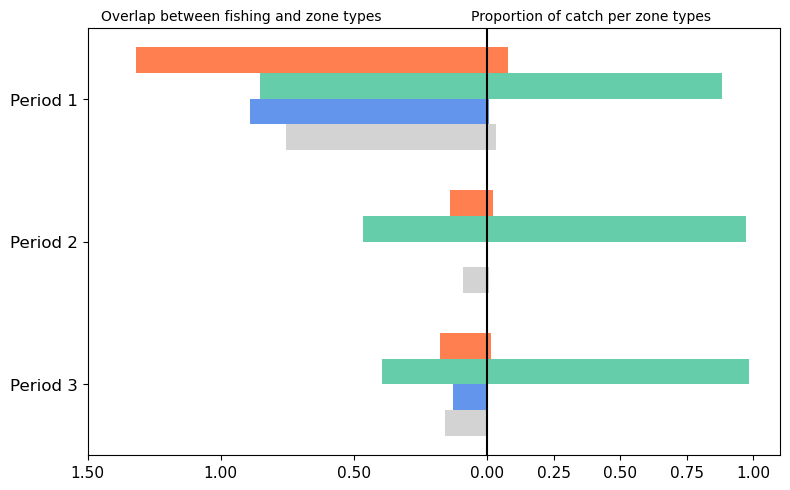

In [86]:
# Couleurs
zone_colors = {
    0: 'lightgrey',
    1: 'cornflowerblue',
    2: 'mediumaquamarine',
    3: 'coral'
}

# Setup du graphique
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.18
periods = ["period_1", "period_2", "period_3"] # + "all_years" ?
zone_types = sorted(data_tornado['Zone_type'].unique(), reverse=True)
y_pos = np.arange(len(periods))

# Boucle par Zone_type
for i, zt in enumerate(zone_types):
    for j, period in enumerate(periods):
        subset = data_tornado[(data_tornado['Zone_type'] == zt) & (data_tornado['Period'] == period)]
        if subset.empty:
            continue

        # Index vertical ajusté par zone
        y = j + (i - 1.5) * bar_width

        # Gauche : True_area (négatif pour barre à gauche, mais valeur positive en label)
        ax.barh(y, -subset['True_area_norm'].values[0],
                height=bar_width, color=zone_colors[zt])

        # Droite : prop_catch
        ax.barh(y, subset['prop_catch'].values[0],
                height=bar_width, color=zone_colors[zt])

# Axe central
ax.axvline(0, color='black')

# Y ticks
ax.set_yticks(y_pos)
ax.set_yticklabels(["Period 1", "Period 2", "Period 3"], fontsize=12)
ax.invert_yaxis()

# Convert x-tick labels to absolute values
x_ticks = np.array([ -1.5, -1 , -0.5,  0 , 0.25,  0.5, 0.75, 1. ]) #ax.get_xticks()
ax.set_xticks(x_ticks)  # Explicitly set the ticks
ax.set_xticklabels([f"{abs(x):.2f}" for x in x_ticks], fontsize=11)

plt.text(-1.45, -0.55, 'Overlap between fishing and zone types', fontsize=10)
plt.text(-0.06, -0.55, 'Proportion of catch per zone types', fontsize=10)

# Légende
# from matplotlib.patches import Patch
# legend_patches = [Patch(color=zone_colors[z], label=f'Zone type {int(z)}') for z in zone_types]
# ax.legend(handles=legend_patches, loc='lower left', fontsize=14)

plt.tight_layout()


# plt.savefig('./figures/tornadoplot_fishing_summer.png',bbox_inches='tight', dpi=300)

plt.show()

In [87]:
data_tornado.iloc[8:11]

,Zone_type,True_area,Period,prop_catch,krill_greenweight_kg,True_area_norm,krill_greenweight_norm,prop_catch_norm
8,0.0,9.029887e+10,period_2,0.006158,2.232308e+06,0.090299,0.002232,0.615766
9,2.0,4.643916e+11,period_2,0.972177,3.524386e+08,0.464392,0.352439,97.217721
10,3.0,1.392570e+11,period_2,0.021665,7.854152e+06,0.139257,0.007854,2.166513


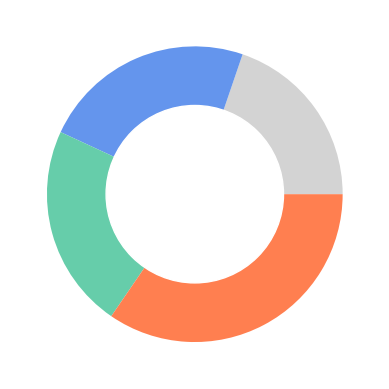

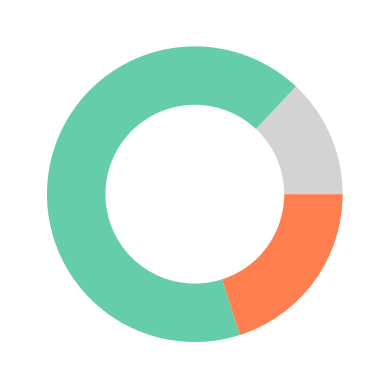

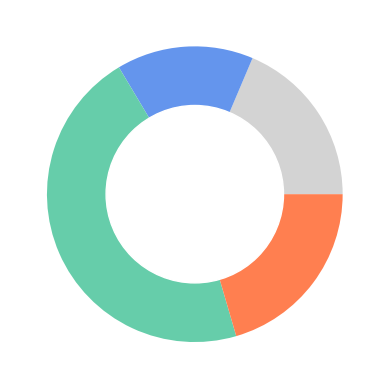

In [89]:
# period 1
data_tornado['True_area_norm'].iloc[4:8].plot.pie(labels=['', '', '', '',''], colors = ['lightgrey','cornflowerblue','mediumaquamarine','coral'], ylabel='')
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
# plt.savefig('./figures/donut_overlap_distrib_p1_summer.png', bbox_inches = 'tight', dpi=300)
plt.show()

#period 2
data_tornado['True_area_norm'].iloc[8:11].plot.pie(labels=['', '', '', '',''], colors = ['lightgrey','mediumaquamarine','coral'], ylabel='')
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
# plt.savefig('./figures/donut_overlap_distrib_p2_summer.png', bbox_inches = 'tight', dpi=300)
plt.show()

# period 3
data_tornado['True_area_norm'].iloc[11:].plot.pie(labels=['', '', '', '',''], colors = ['lightgrey','cornflowerblue','mediumaquamarine','coral'], ylabel='')
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
# plt.savefig('./figures/donut_overlap_distrib_p3_summer.png', bbox_inches = 'tight', dpi=300)
plt.show()

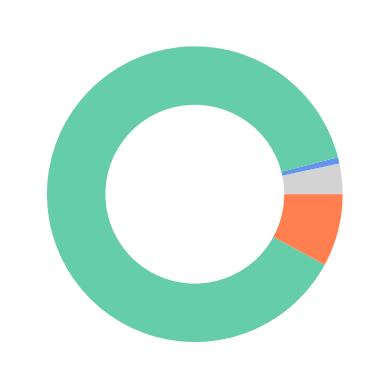

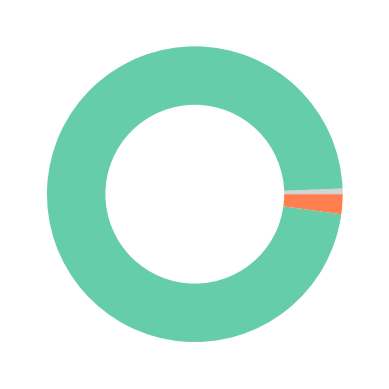

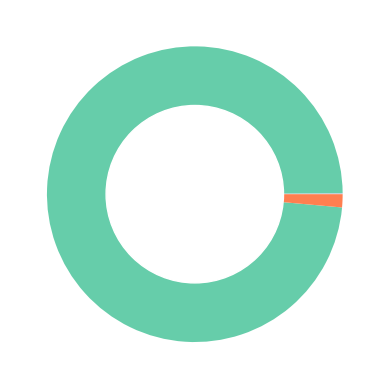

In [91]:
# period 1
data_tornado['krill_greenweight_norm'].iloc[4:8].plot.pie(labels=['', '', '', '',''], colors = ['lightgrey','cornflowerblue','mediumaquamarine','coral'], ylabel='')
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
# plt.savefig('./figures/donut_catch_distrib_p1_summer.png', bbox_inches = 'tight', dpi=300)
plt.show()

#period 2
data_tornado['krill_greenweight_norm'].iloc[8:11].plot.pie(labels=['', '', '', '',''], colors = ['lightgrey','mediumaquamarine','coral'], ylabel='')
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
# plt.savefig('./figures/donut_catch_distrib_p2_summer.png', bbox_inches = 'tight', dpi=300)
plt.show()

# period 3
data_tornado['krill_greenweight_norm'].iloc[11:].plot.pie(labels=['', '', '', '',''], colors = ['lightgrey','cornflowerblue','mediumaquamarine','coral'], ylabel='')
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
# plt.savefig('./figures/donut_catch_distrib_p3_summer.png', bbox_inches = 'tight', dpi=300)
plt.show()

In [92]:
data_tornado[['Period', 'Zone_type', 'prop_catch_norm']]

,Period,Zone_type,prop_catch_norm
0,all_years,0.0,1.220581
1,all_years,1.0,0.232537
2,all_years,2.0,94.912584
3,all_years,3.0,3.634298
4,period_1,0.0,3.332242
5,period_1,1.0,0.686712
6,period_1,2.0,88.073115
7,period_1,3.0,7.907931
8,period_2,0.0,0.615766
9,period_2,2.0,97.217721


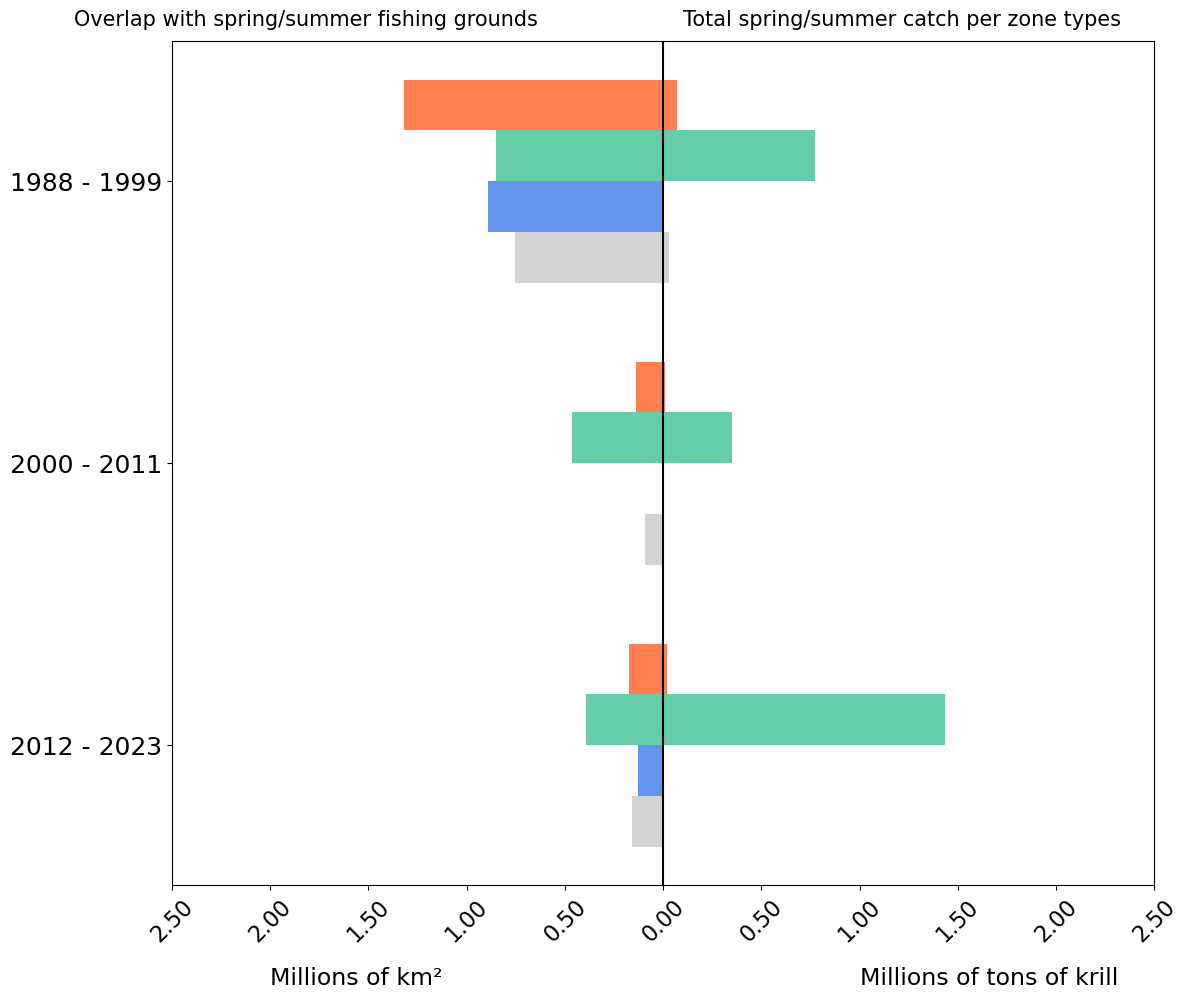

In [104]:
# Couleurs
zone_colors = {
    0: 'lightgrey',
    1: 'cornflowerblue',
    2: 'mediumaquamarine',
    3: 'coral'
}

# Setup du graphique
fig, ax = plt.subplots(figsize=(12, 10))

bar_width = 0.18
periods = ["period_1", "period_2", "period_3"] # + "all_years" ?
zone_types = sorted(data_tornado['Zone_type'].unique(), reverse=True)
y_pos = np.arange(len(periods))

# Boucle par Zone_type
for i, zt in enumerate(zone_types):
    for j, period in enumerate(periods):
        subset = data_tornado[(data_tornado['Zone_type'] == zt) & (data_tornado['Period'] == period)]
        if subset.empty:
            continue

        # Index vertical ajusté par zone
        y = j + (i - 1.5) * bar_width

        # Gauche : True_area (négatif pour barre à gauche, mais valeur positive en label)
        ax.barh(y, -subset['True_area_norm'].values[0],
                height=bar_width, color=zone_colors[zt])

        # Droite : prop_catch
        ax.barh(y, subset['krill_greenweight_norm'].values[0],
                height=bar_width, color=zone_colors[zt])

# Axe central
ax.axvline(0, color='black')

# Y ticks
ax.set_yticks(y_pos)
ax.set_yticklabels(["1988 - 1999", "2000 - 2011", "2012 - 2023"], fontsize=18)
ax.invert_yaxis()

# Convert x-tick labels to absolute values
x_ticks = np.array([-2.5,-2, -1.5, -1 , -0.5,  0 , 0.5, 1. , 1.5, 2, 2.5]) #ax.get_xticks()
ax.set_xticks(x_ticks)  # Explicitly set the ticks
ax.set_xticklabels([f"{abs(x):.2f}" for x in x_ticks], fontsize=16, rotation=45)

plt.text(-3, -0.55, 'Overlap with spring/summer fishing grounds ', fontsize=15)
plt.text(0.1, -0.55, 'Total spring/summer catch per zone types ', fontsize=15)

plt.text(-2, 2.85, 'Millions of km²', fontsize=17)
plt.text(1, 2.85, 'Millions of tons of krill', fontsize=17)

# Légende
# from matplotlib.patches import Patch
# legend_patches = [Patch(color=zone_colors[z], label=f'Zone type {int(z)}') for z in zone_types]
# ax.legend(handles=legend_patches, loc='lower left', fontsize=14)

plt.tight_layout()


# plt.savefig('./figures/tornadoplot_fishing_totcatch_summer.png',bbox_inches='tight', dpi=300)

plt.show()